# 05 · Classic Problems — the pattern library

Most optimization problems you meet are variations on a handful of **shapes**. Learn
to recognise them and formulation becomes pattern-matching. This notebook walks three
classics, each a template you will reuse:

- **Blending / diet** — least-cost mix hitting a spec (the first LP solved industrially).
- **Assignment** — match workers to jobs one-to-one at minimum cost.
- **Transportation** — ship from plants to warehouses at minimum cost.

Each connects forward: transportation and facility location to `supply_chain_arena`,
assignment and routing to `routing_arena`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from src.datasets.scenarios import (
    assignment_scenario,
    blending_scenario,
    transportation_scenario,
)
from src.evaluation.optimum_check import brute_force_assignment_scenario
from src.exporters import save_fig, save_json
from src.models import assignment, blending
from src.solvers.backends import solve

results = {}

## Blending / diet — least cost meeting a spec

Choose how much of each food to buy to **minimise cost** while meeting every
nutrient minimum. Decision variables: quantities of each food. Objective: total cost.
Constraints: each nutrient `>=` its requirement. Historically the very first LP.

cost   : 18.0
amounts: {'grain': 2.0, 'meat': 6.0}


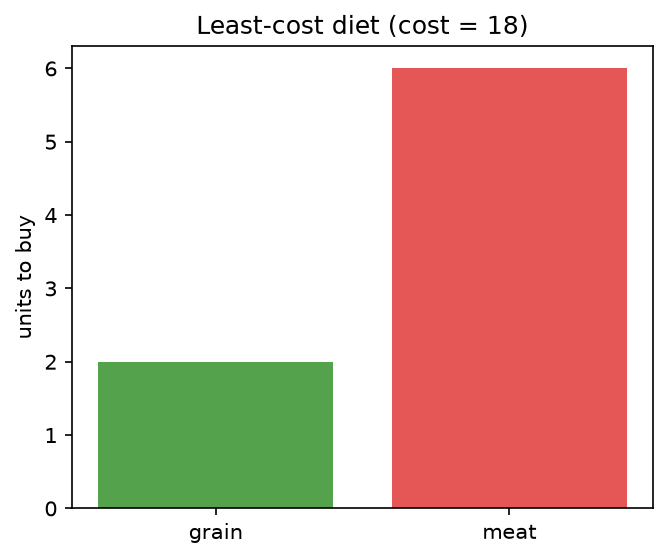

In [2]:
diet = blending_scenario()
sol = solve(blending.build(diet), backend="scipy")
amounts = {f: sol.value(f) for f in diet.foods}
print("cost   :", round(sol.objective, 2))
print("amounts:", {k: round(v, 3) for k, v in amounts.items()})
assert abs(sol.objective - diet.optimum) < 1e-6
results["blending"] = {
    "inputs": {"cost": diet.cost, "content": diet.content, "minimum": diet.minimum},
    "optimum_cost": sol.objective,
    "amounts": amounts,
}

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(list(amounts), list(amounts.values()), color=["#54a24b", "#e45756"])
ax.set_ylabel("units to buy")
ax.set_title(f"Least-cost diet (cost = {sol.objective:.0f})")
path = save_fig(fig, "05_blending")
plt.close(fig)
Image(str(path))

## Assignment — one-to-one at minimum cost

Match each worker to exactly one job and each job to exactly one worker, minimising
total cost. Although the "one-to-one" decisions sound integer, the constraint matrix
is **totally unimodular**, so the LP relaxation already returns a whole-number
assignment for free. We confirm the solver's cost by brute-forcing all permutations.

In [3]:
asn = assignment_scenario()
sol = solve(assignment.build_assignment(asn), backend="scipy")
chosen = {
    w: j
    for wi, w in enumerate(asn.workers)
    for j in asn.jobs
    if sol.value(f"x_{w}_{j}") > 0.5
}
bf = brute_force_assignment_scenario(asn)
print("assignment:", chosen)
print("cost      :", round(sol.objective, 2), "| brute force:", bf)
assert abs(sol.objective - bf) < 1e-6
results["assignment"] = {
    "cost_matrix": [list(row) for row in asn.cost],
    "optimum_cost": sol.objective,
    "assignment": chosen,
    "brute_force_cost": bf,
    "integral": all(abs(v - round(v)) < 1e-6 for v in sol.values.values()),
}

assignment: {'W1': 'J2', 'W2': 'J1', 'W3': 'J3'}
cost      : 9.0 | brute force: 9.0


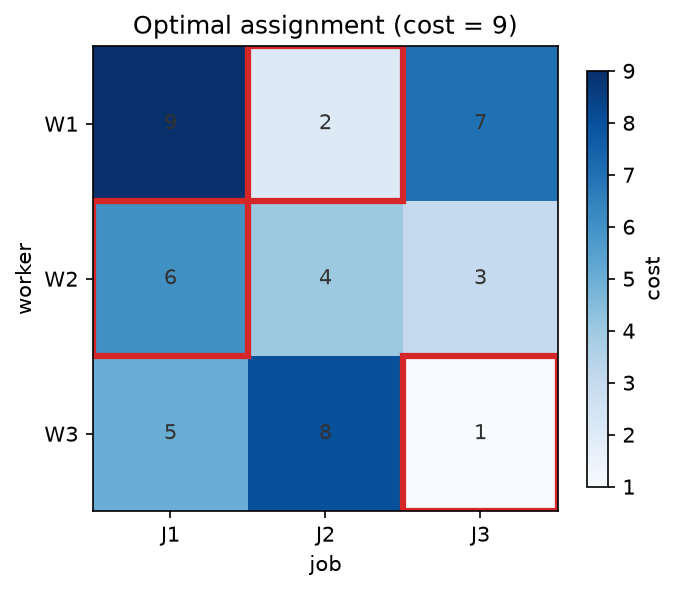

In [4]:
cost = np.array(asn.cost)
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cost, cmap="Blues")
ax.set_xticks(range(len(asn.jobs)), asn.jobs)
ax.set_yticks(range(len(asn.workers)), asn.workers)
ax.set_xlabel("job")
ax.set_ylabel("worker")
for wi in range(len(asn.workers)):
    for ji in range(len(asn.jobs)):
        ax.text(ji, wi, f"{cost[wi, ji]:.0f}", ha="center", va="center", color="#333")
for wi, w in enumerate(asn.workers):  # outline the chosen cells
    ji = asn.jobs.index(chosen[w])
    ax.add_patch(plt.Rectangle((ji - 0.5, wi - 0.5), 1, 1, fill=False,
                               edgecolor="#d62728", linewidth=3))
ax.set_title(f"Optimal assignment (cost = {sol.objective:.0f})")
fig.colorbar(im, ax=ax, shrink=0.8, label="cost")
path = save_fig(fig, "05_assignment")
plt.close(fig)
Image(str(path))

## Transportation — plants to warehouses at minimum cost

Ship units from plants (each with a supply) to warehouses (each with a demand) at
minimum total cost. Decision variables: how much to ship on each lane. Constraints:
do not exceed supply, meet demand. The optimal shipment plan uses the cheap lanes
first, subject to the balances.

cost : 465.0
flows:
 [[ 0. 20.  0.]
 [10.  5. 15.]]


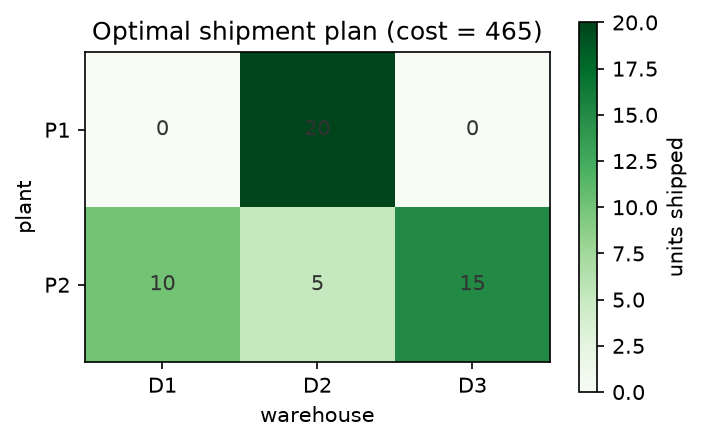

In [5]:
trp = transportation_scenario()
sol = solve(assignment.build_transportation(trp), backend="scipy")
flow = np.array([[sol.value(f"ship_{p}_{d}") for d in trp.warehouses] for p in trp.plants])
print("cost :", round(sol.objective, 2))
print("flows:\n", flow)
assert abs(sol.objective - trp.optimum) < 1e-6
results["transportation"] = {
    "supply": trp.supply,
    "demand": trp.demand,
    "cost": {f"{p}->{d}": v for (p, d), v in trp.cost.items()},
    "optimum_cost": sol.objective,
    "flows": {f"{p}->{d}": sol.value(f"ship_{p}_{d}") for p in trp.plants for d in trp.warehouses},
}

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(flow, cmap="Greens")
ax.set_xticks(range(len(trp.warehouses)), trp.warehouses)
ax.set_yticks(range(len(trp.plants)), trp.plants)
ax.set_xlabel("warehouse")
ax.set_ylabel("plant")
for pi in range(len(trp.plants)):
    for di in range(len(trp.warehouses)):
        ax.text(di, pi, f"{flow[pi, di]:.0f}", ha="center", va="center", color="#333")
ax.set_title(f"Optimal shipment plan (cost = {sol.objective:.0f})")
fig.colorbar(im, ax=ax, shrink=0.8, label="units shipped")
path = save_fig(fig, "05_transportation")
plt.close(fig)
Image(str(path))

In [6]:
save_json(results, "05_classic_problems")
print("saved 05_classic_problems.json with:", list(results))

saved 05_classic_problems.json with: ['blending', 'assignment', 'transportation']


## A catalog of shapes

You now have three templates — blending, assignment, transportation — plus the
product mix (02) and the knapsack / facility problems (04). Recognising which shape a
business question fits is most of the work; the solver does the rest.

In **notebook 06** we open the engine: a from-scratch simplex, then a tour of the
open-source solvers, all agreeing on the same model.